# Data Collection

In [2]:
import pandas as pd

df_games = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/results_1872_2026.csv')
df_ranking = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/wc_2026_48_teams_fifa_rank_change_corrected.csv')
df_group_stage = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/reference/group_stages.csv', sep=';')
df_knockout_fixtures = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/reference/fixtures_knockout_wc2026.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### All games from 1872 - 2026

In [3]:
print(df_games.shape)
df_games.head()

(49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
# Last 72 rows are all for the WC 2026
df_games.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49286,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


### Fifa Ranking in 2022 and 2026

In [5]:
print(df_ranking.shape)
df_ranking.head()

(48, 4)


,Nation,FIFA_2022_ranking,FIFA_2026_rank,rank_change
0,France,3,1,2
1,Spain,10,2,8
2,Argentina,2,3,-1
3,England,5,4,1
4,Portugal,9,5,4


In [6]:
df_ranking['Nation'].unique()

<StringArray>
[                'France',                  'Spain',              'Argentina',
                'England',               'Portugal',                 'Brazil',
            'Netherlands',                'Morocco',                'Belgium',
                'Germany',                'Croatia',               'Colombia',
                'Senegal',                 'Mexico',          'United States',
                'Uruguay',                  'Japan',            'Switzerland',
                   'Iran',                 'Turkey',                'Ecuador',
                'Austria',            'South Korea',              'Australia',
                'Algeria',                  'Egypt',                 'Canada',
                 'Norway',                 'Panama',            'Ivory Coast',
                 'Sweden',               'Paraguay',         'Czech Republic',
               'Scotland',                'Tunisia',               'DR Congo',
             'Uzbekistan',            

### Group stages

In [7]:
print(df_group_stage.shape)
df_group_stage.head(10)

(48, 3)


,group,position,nation
0,A,1,Mexico
1,A,2,South Africa
2,A,3,South Korea
3,A,4,Czech Republic
4,B,1,Canada
5,B,2,Bosnia and Herzegovina
6,B,3,Qatar
7,B,4,Switzerland
8,C,1,Brazil
9,C,2,Morocco


### Knockout Fixtures Grid

In [8]:
print(df_knockout_fixtures.shape)
df_knockout_fixtures.head()

(32, 8)


,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to
0,M73,R32,2026-06-28,20:00,2A,2B,M90,NaN
1,M74,R32,2026-06-29,21:30,1E,3ABCDF,M89,NaN
2,M75,R32,2026-06-30,02:00,1F,2C,M90,NaN
3,M76,R32,2026-06-29,18:00,1C,2F,M91,NaN
4,M77,R32,2026-06-30,22:00,1I,3CDFGH,M89,NaN


# Data Cleaning

In [9]:
print(df_games.shape)
df_games.head()

(49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [10]:
df_games.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49286,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


In [11]:
# Split into historical matches and WC2026 fixtures
historical_matches = df_games[df_games['home_score'].notna()].copy()
wc2026_fixtures = df_games[df_games['home_score'].isna()].copy()

In [12]:
print(historical_matches.shape)
historical_matches.head(1)

(49215, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False


In [13]:
print(wc2026_fixtures.shape)
wc2026_fixtures.head(1)

(72, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49215,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False


In [15]:
# Save to CSV
historical_matches.to_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/interim/historical_matches.csv', index=False)
wc2026_fixtures.to_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/interim/wc2026_fixtures.csv', index=False)

print(f"Historical matches: {len(historical_matches)}")
print(f"WC2026 fixtures: {len(wc2026_fixtures)}")

Historical matches: 49215
WC2026 fixtures: 72


# Feature Engineering

In [17]:
df_games = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/interim/historical_matches.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [18]:
print(df_games.shape)
df_games.head(2)

(49215, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False


In [21]:
df_games['tournament'].value_counts().head()

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Name: count, dtype: int64

In [22]:
# Exclude non-FIFA tournaments / Matches

df_games = df_games[~df_games['tournament'].str.startswith('CONIFA')]
df_games = df_games[~df_games['tournament'].str.startswith('ConIFA')]

print(df_games.shape)

(49048, 9)


### Compute ELO ratings for every international team over history

In [23]:
import pandas as pd
from collections import defaultdict

# ============================================================
# Compute Elo ratings for every international team over history
# ============================================================

# ---------- 1. K-factor tiers by tournament importance ----------
TIER_1_WORLD_CUP = {'FIFA World Cup'}

TIER_2_CONTINENTAL = {
    'UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup',
    'Gold Cup', 'CONCACAF Championship', 'Oceania Nations Cup',
    'Confederations Cup',
}

TIER_3_QUALIFIERS_NATIONS = {
    'FIFA World Cup qualification', 'UEFA Euro qualification',
    'African Cup of Nations qualification', 'AFC Asian Cup qualification',
    'Gold Cup qualification', 'CONCACAF Championship qualification',
    'Copa América qualification', 'Oceania Nations Cup qualification',
    'UEFA Nations League', 'CONCACAF Nations League',
    'CONCACAF Nations League qualification',
}

TIER_4_REGIONAL = {
    # Africa
    'CECAFA Cup', 'COSAFA Cup', 'COSAFA Cup qualification', 'WAFF Championship',
    'Amílcar Cabral Cup', 'All-African Games', 'UDEAC Cup', 'UNIFFAC Cup',
    'West African Cup', 'Nile Basin Tournament', 'African Friendship Games',
    # Asia / Oceania
    'Gulf Cup', 'Arab Cup', 'Arab Cup qualification', 'SAFF Cup',
    'AFF Championship', 'AFF Championship qualification', 'EAFF Championship',
    'EAFF Championship qualification', 'ASEAN Championship',
    'ASEAN Championship qualification', 'AFC Challenge Cup',
    'AFC Challenge Cup qualification', 'Asian Games', 'CAFA Nations Cup',
    'Southeast Asian Games', 'South Asian Games', 'Dynasty Cup',
    'Pacific Games', 'South Pacific Games', 'Melanesia Cup',
    'Indian Ocean Island Games', 'Afro-Asian Games',
    # Europe
    'British Home Championship', 'Nordic Championship', 'Baltic Cup',
    'Balkan Cup', 'Central European International Cup',
    # Americas
    'CFU Caribbean Cup', 'CFU Caribbean Cup qualification', 'UNCAF Cup',
    'Central American and Caribbean Games', 'Pan American Championship',
    'CCCF Championship', 'Bolivarian Games', 'NAFC Championship',
    # Multi-sport
    'Olympic Games',
}

TIER_5_FRIENDLY = {'Friendly', 'FIFA Series', 'CONCACAF Series'}


def get_k_factor(tournament):
    """K controls how reactive Elo is to a match. Higher = bigger swings."""
    if tournament in TIER_1_WORLD_CUP:          return 60
    if tournament in TIER_2_CONTINENTAL:        return 50
    if tournament in TIER_3_QUALIFIERS_NATIONS: return 40
    if tournament in TIER_4_REGIONAL:           return 30
    if tournament in TIER_5_FRIENDLY:           return 20
    return 15   # minor/exhibition tournaments, anniversary cups, etc.


# ---------- 2. Expected score formula ----------
def expected_score(home_elo, away_elo, home_advantage=100):
    # home_advantage = 100 → ~64% win rate for evenly matched home teams.
    # Set to 0 for neutral-venue matches (the formula then becomes symmetric).
    diff = (home_elo + home_advantage) - away_elo
    return 1 / (1 + 10 ** (-diff / 400))


# ---------- 3. Load and prepare ----------
df = df_games.copy()
df = df.dropna(subset=['home_score', 'away_score'])

# Drop CONIFA tournaments — these only involve non-FIFA teams
df = df[~df['tournament'].str.contains('CONIFA', case=False, na=False)]

df = df.sort_values('date').reset_index(drop=True)
print(f"Computing Elo over {len(df):,} historical matches")

# ---------- 4. Iterate through history ----------
INITIAL_ELO = 1500
current_elo = defaultdict(lambda: INITIAL_ELO)
elo_history = []

for row in df.itertuples(index=False):
    home, away = row.home_team, row.away_team
    home_elo, away_elo = current_elo[home], current_elo[away]

    # Neutral venue cancels home advantage
    h_adv = 0 if row.neutral else 100
    exp_home = expected_score(home_elo, away_elo, h_adv)
    exp_away = 1 - exp_home

    # Actual result
    if row.home_score > row.away_score:
        actual_home, actual_away = 1.0, 0.0
    elif row.home_score < row.away_score:
        actual_home, actual_away = 0.0, 1.0
    else:
        actual_home, actual_away = 0.5, 0.5

    # Goal-difference multiplier — bigger wins move Elo more
    goal_diff = abs(row.home_score - row.away_score)
    if goal_diff <= 1:
        g = 1.0
    elif goal_diff == 2:
        g = 1.5
    else:
        g = (11 + goal_diff) / 8

    K = get_k_factor(row.tournament)

    # Update both teams (zero-sum: total Elo across the two teams is preserved)
    current_elo[home] = home_elo + K * g * (actual_home - exp_home)
    current_elo[away] = away_elo + K * g * (actual_away - exp_away)

    elo_history.append((row.date, home, current_elo[home]))
    elo_history.append((row.date, away, current_elo[away]))

# ---------- 5. Build the lookup table ----------
df_elo = pd.DataFrame(elo_history, columns=['date', 'team', 'elo_after'])
df_elo['date'] = pd.to_datetime(df_elo['date'])
print(f"df_elo shape: {df_elo.shape}")

# ---------- 6. Sanity checks ----------
print("\n--- Top 15 current Elo ---")
current_ranking = (
    df_elo.sort_values('date')
          .groupby('team')
          .tail(1)
          .sort_values('elo_after', ascending=False)
          .head(15)
)
print(current_ranking.to_string(index=False))

print("\n--- Bottom 15 current Elo (sanity: should be tiny non-FIFA or minnow teams) ---")
print(
    df_elo.sort_values('date')
          .groupby('team')
          .tail(1)
          .sort_values('elo_after')
          .head(15)
          .to_string(index=False)
)

print(f"\nTotal unique teams with Elo: {df_elo['team'].nunique()}")

Computing Elo over 49,048 historical matches
df_elo shape: (98096, 3)

--- Top 15 current Elo ---
      date        team   elo_after
2026-03-31       Spain 2220.668648
2026-03-31   Argentina 2180.246575
2026-03-29      France 2137.182107
2026-03-31     England 2078.893971
2026-03-31      Brazil 2062.818926
2026-03-29    Colombia 2051.621962
2026-03-31    Portugal 2034.648091
2026-03-31     Ecuador 2018.272845
2026-03-31 Netherlands 2016.511156
2026-03-30     Germany 1988.982584
2026-03-31     Croatia 1982.130309
2026-03-31     Morocco 1981.410473
2026-03-31       Japan 1978.864707
2026-03-31     Uruguay 1972.555119
2026-03-31      Norway 1961.244369

--- Bottom 15 current Elo (sanity: should be tiny non-FIFA or minnow teams) ---
      date                         team   elo_after
2026-03-29                        Macau  861.915259
2025-11-18                       Bhutan  876.100843
2026-03-29                     Anguilla  899.114241
2025-11-18                       Brunei  907.510912
2

### FIFA ranking and highly correlated but not identical - exactly what you want

##### neutral-flag distribution

In [24]:
print("Neutral venue distribution:")
print(df_games['neutral'].value_counts(normalize=True))
print("\nNeutral by tournament (top 10):")
print(df_games.groupby('tournament')['neutral']
              .mean()
              .sort_values(ascending=False)
              .head())

Neutral venue distribution:
neutral
False    0.738195
True     0.261805
Name: proportion, dtype: float64

Neutral by tournament (top 10):
tournament
Al Ain International Cup            1.0
Tynwald Hill Tournament             1.0
Outrigger Challenge Cup             1.0
Real Madrid 75th Anniversary Cup    1.0
Unity Cup                           1.0
Name: neutral, dtype: float64


### Quick Checks

In [25]:
# Spot check: Morocco should have spiked after WC2022
morocco = df_elo[df_elo['team'] == 'Morocco'].sort_values('date')
print(morocco.tail(20))   # look for jump around Dec 2022

# Spot check: a team that played few matches should be near 1500
print(df_elo[df_elo['team'] == 'Anguilla'].tail(5))

            date     team    elo_after
96849 2025-09-08  Morocco  1923.634935
97018 2025-10-09  Morocco  1924.916547
97280 2025-10-14  Morocco  1925.643214
97396 2025-11-14  Morocco  1926.680570
97564 2025-11-18  Morocco  1929.022437
97636 2025-12-02  Morocco  1932.438844
97653 2025-12-05  Morocco  1920.795340
97668 2025-12-08  Morocco  1927.869667
97680 2025-12-11  Morocco  1932.011323
97690 2025-12-15  Morocco  1941.613564
97693 2025-12-18  Morocco  1950.456477
97694 2025-12-21  Morocco  1953.029306
97724 2025-12-26  Morocco  1934.337446
97746 2025-12-29  Morocco  1939.592641
97772 2026-01-04  Morocco  1941.321060
97784 2026-01-09  Morocco  1951.783809
97792 2026-01-14  Morocco  1938.775828
97798 2026-01-18  Morocco  1971.653463
97920 2026-03-27  Morocco  1972.941440
98090 2026-03-31  Morocco  1981.410473
            date      team   elo_after
96330 2025-06-07  Anguilla  887.863882
97297 2025-11-12  Anguilla  902.034635
97425 2025-11-15  Anguilla  894.689058
97841 2026-03-26  Anguill

In [27]:
df_games.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [28]:
df_elo.head()

,date,team,elo_after
0,1872-11-30,Scotland,1497.198700
1,1872-11-30,England,1502.801300
2,1873-03-08,England,1513.377469
3,1873-03-08,Scotland,1486.622531
4,1874-03-07,Scotland,1494.545054


### Elo impact on fixtures (with Leakage but removed later)

In [29]:
# For each historical match, find each team's Elo state around that match.
# We'll grab BOTH the pre-match Elo (legitimate feature) and the post-match Elo
# (which we'll use to demonstrate target leakage, then drop before training).

df_games['date'] = pd.to_datetime(df_games['date'])
df_elo['date']   = pd.to_datetime(df_elo['date'])

df_elo_sorted   = df_elo.sort_values('date').reset_index(drop=True)
df_games_sorted = df_games.sort_values('date').reset_index(drop=True)

# ----- HOME: pre-match Elo (lookup strictly BEFORE the match date) -----
df_temp = pd.merge_asof(
    df_games_sorted,
    df_elo_sorted.rename(columns={'team': 'home_team', 'elo_after': 'home_elo_pre'}),
    on='date',
    by='home_team',
    direction='backward',
    allow_exact_matches=False,   # exclude same-day entries → no leakage
)

# ----- HOME: post-match Elo (lookup ON the match date — this is the leak) -----
df_temp = pd.merge_asof(
    df_temp.sort_values('date'),
    df_elo_sorted.rename(columns={'team': 'home_team', 'elo_after': 'home_elo_after'}),
    on='date',
    by='home_team',
    direction='backward',
    allow_exact_matches=True,    # INCLUDE same-day → grabs the post-match update
)

# ----- AWAY: pre-match Elo -----
df_temp = pd.merge_asof(
    df_temp.sort_values('date'),
    df_elo_sorted.rename(columns={'team': 'away_team', 'elo_after': 'away_elo_pre'}),
    on='date',
    by='away_team',
    direction='backward',
    allow_exact_matches=False,
)

# ----- AWAY: post-match Elo (the leak again) -----
df_match_features = pd.merge_asof(
    df_temp.sort_values('date'),
    df_elo_sorted.rename(columns={'team': 'away_team', 'elo_after': 'away_elo_after'}),
    on='date',
    by='away_team',
    direction='backward',
    allow_exact_matches=True,
)

df_match_features['elo_diff'] = (
    df_match_features['home_elo_pre'] - df_match_features['away_elo_pre']
)

# Inspect: pre vs after side by side
df_match_features[[
    'date', 'home_team', 'away_team', 'home_score', 'away_score',
    'home_elo_pre', 'home_elo_after', 'away_elo_pre', 'away_elo_after'
]].tail(10)

,date,home_team,away_team,home_score,away_score,home_elo_pre,home_elo_after,away_elo_pre,away_elo_after
49038,2026-03-31,Iraq,Bolivia,2.0,1.0,1710.777393,1733.899556,1765.462067,1742.339904
49039,2026-03-31,Bosnia and Herzegovina,Italy,1.0,1.0,1632.960817,1642.884095,1922.036782,1912.113504
49040,2026-03-31,Sweden,Poland,3.0,2.0,1754.883707,1771.742389,1799.857926,1782.999243
49041,2026-03-31,Kosovo,Turkey,0.0,1.0,1789.903507,1772.593654,1936.921078,1954.230931
49042,2026-03-31,Czech Republic,Denmark,2.0,2.0,1773.840408,1776.737286,1924.520757,1921.623879
49043,2026-03-31,Peru,Honduras,2.0,2.0,1763.677644,1762.044919,1706.438665,1708.071391
49044,2026-03-31,Spain,Egypt,0.0,0.0,2229.756779,2220.668648,1801.424265,1810.512397
49045,2026-03-31,Wales,Northern Ireland,1.0,1.0,1757.649465,1752.167437,1643.695753,1649.177781
49046,2026-03-31,Australia,Curaçao,5.0,1.0,1883.419176,1887.564123,1621.162116,1617.017169
49047,2026-03-31,Kazakhstan,Comoros,1.0,0.0,1489.055719,1496.246250,1488.747627,1481.557097


### Elo on fixtures

In [30]:
# For each historical match, find each team's Elo *just before* that match.
# (You want pre-match Elo as the feature, not post-match — post-match would leak the result.)

df_games['date'] = pd.to_datetime(df_games['date'])
df_elo['date'] = pd.to_datetime(df_elo['date'])

df_elo_sorted = df_elo.sort_values('date').reset_index(drop=True)

# Use merge_asof for "find the most recent Elo entry before this match date"
df_games_sorted = df_games.sort_values('date').reset_index(drop=True)

# Home team Elo at time of match
df_with_home_elo = pd.merge_asof(
    df_games_sorted,
    df_elo_sorted.rename(columns={'team': 'home_team', 'elo_after': 'home_elo_pre'}),
    on='date',
    by='home_team',
    direction='backward',
    allow_exact_matches=False  # don't pick up the *current* match's post-Elo
)

# Same for away team
df_match_features = pd.merge_asof(
    df_with_home_elo.sort_values('date'),
    df_elo_sorted.rename(columns={'team': 'away_team', 'elo_after': 'away_elo_pre'}),
    on='date',
    by='away_team',
    direction='backward',
    allow_exact_matches=False
)

df_match_features['elo_diff'] = df_match_features['home_elo_pre'] - df_match_features['away_elo_pre']

In [31]:
print(df_match_features.shape)
df_match_features.tail(2)

(49048, 12)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff
49046,2026-03-31,Australia,Curaçao,5.0,1.0,FIFA Series,Melbourne,Australia,False,1883.419176,1621.162116,262.257060
49047,2026-03-31,Kazakhstan,Comoros,1.0,0.0,FIFA Series,Astana,Kazakhstan,False,1489.055719,1488.747627,0.308092


In [32]:
assert 'home_elo_after' not in df_match_features.columns
assert 'away_elo_after' not in df_match_features.columns
assert 'home_elo_change' not in df_match_features.columns
print("✓ No leaky columns")

✓ No leaky columns


In [35]:
df_match_features.to_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/processed/df_match_features.csv', index=False)
print(f"Saved: {df_match_features.shape}")

Saved: (49048, 12)


# Feature Engineering Match Metadata

In [37]:
df = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/processed/df_match_features.csv', parse_dates=['date'])
conf = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/reference/FIFA_confederations.csv')
df_groups = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/reference/group_stages.csv', sep=';')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [38]:
print(df.shape)
df.head(3)

(49048, 12)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.801300,1497.198700,5.602600
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1486.622531,1513.377469,-26.754938


### Section 0 - Load and Handle Elo NaN

In [39]:
# Fill cold-start Elo NaNs with starting value
df['home_elo_pre'] = df['home_elo_pre'].fillna(1500)
df['away_elo_pre'] = df['away_elo_pre'].fillna(1500)
df['elo_diff'] = df['home_elo_pre'] - df['away_elo_pre']

print(df.shape)
print("Remaining NaN in Elo:", df[['home_elo_pre', 'away_elo_pre']].isna().sum().sum())

(49048, 12)
Remaining NaN in Elo: 0


In [40]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000,0.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.801300,1497.198700,5.602600
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1486.622531,1513.377469,-26.754938
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1505.454946,1494.545054,10.909891
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1497.633108,1502.366892,-4.733783


### Section 1 - Tournament TIERS + tournament_weight

In [41]:
# Tournament tier sets — same buckets used for Elo K-factor in Notebook 2.
# Re-defined here because notebooks don't share state.

TIER_1_WORLD_CUP = {'FIFA World Cup'}

TIER_2_CONTINENTAL = {
    'UEFA Euro', 'Copa América', 'African Cup of Nations', 'AFC Asian Cup',
    'Gold Cup', 'CONCACAF Championship', 'Oceania Nations Cup',
    'Confederations Cup',
}

TIER_3_QUALIFIERS_NATIONS = {
    'FIFA World Cup qualification', 'UEFA Euro qualification',
    'African Cup of Nations qualification', 'AFC Asian Cup qualification',
    'Gold Cup qualification', 'CONCACAF Championship qualification',
    'Copa América qualification', 'Oceania Nations Cup qualification',
    'UEFA Nations League', 'CONCACAF Nations League',
    'CONCACAF Nations League qualification',
}

TIER_4_REGIONAL = {
    # Africa
    'CECAFA Cup', 'COSAFA Cup', 'COSAFA Cup qualification', 'WAFF Championship',
    'Amílcar Cabral Cup', 'All-African Games', 'UDEAC Cup', 'UNIFFAC Cup',
    'West African Cup', 'Nile Basin Tournament', 'African Friendship Games',
    # Asia / Oceania
    'Gulf Cup', 'Arab Cup', 'Arab Cup qualification', 'SAFF Cup',
    'AFF Championship', 'AFF Championship qualification', 'EAFF Championship',
    'EAFF Championship qualification', 'ASEAN Championship',
    'ASEAN Championship qualification', 'AFC Challenge Cup',
    'AFC Challenge Cup qualification', 'Asian Games', 'CAFA Nations Cup',
    'Southeast Asian Games', 'South Asian Games', 'Dynasty Cup',
    'Pacific Games', 'South Pacific Games', 'Melanesia Cup',
    'Indian Ocean Island Games', 'Afro-Asian Games',
    # Europe
    'British Home Championship', 'Nordic Championship', 'Baltic Cup',
    'Balkan Cup', 'Central European International Cup',
    # Americas
    'CFU Caribbean Cup', 'CFU Caribbean Cup qualification', 'UNCAF Cup',
    'Central American and Caribbean Games', 'Pan American Championship',
    'CCCF Championship', 'Bolivarian Games', 'NAFC Championship',
    # Multi-sport
    'Olympic Games',
}

In [42]:
def tournament_weight(t):
    if t in TIER_1_WORLD_CUP:          return 5
    if t in TIER_2_CONTINENTAL:        return 4
    if t in TIER_3_QUALIFIERS_NATIONS: return 3
    if t in TIER_4_REGIONAL:           return 2
    return 1   # friendlies + minor exhibitions

df['tournament_weight'] = df['tournament'].apply(tournament_weight)
print(df['tournament_weight'].value_counts().sort_index())

tournament_weight
1    21824
2     6692
3    16177
4     3391
5      964
Name: count, dtype: int64


### Section 2 - is_competitive

- If not friendly then competitive

In [43]:
df['is_competitive'] = df['tournament'] != 'Friendly'
print(df['is_competitive'].value_counts())

is_competitive
True     30796
False    18252
Name: count, dtype: int64


### Section 3 - Confederation merge

In [44]:
df = df.merge(
    conf.rename(columns={'nation': 'home_team', 'confederation': 'home_confederation'}),
    on='home_team', how='left'
)
df = df.merge(
    conf.rename(columns={'nation': 'away_team', 'confederation': 'away_confederation'}),
    on='away_team', how='left'
)

print("Missing home confederation:", df['home_confederation'].isna().sum())
print("Missing away confederation:", df['away_confederation'].isna().sum())

Missing home confederation: 31727
Missing away confederation: 33026


**Note:**

FIFA_confederations.csv only has the 48 qualified teams. So thousands of historical matches will get NaN for confederation — Czechoslovakia, Yugoslavia, Bolivia, Senegal in 1990, etc.

We fill empty values with 'unknown'

In [45]:
df['home_confederation'] = df['home_confederation'].fillna('Unknown')
df['away_confederation'] = df['away_confederation'].fillna('Unknown')

In [46]:
print("Missing home confederation:", df['home_confederation'].isna().sum())
print("Missing away confederation:", df['away_confederation'].isna().sum())

Missing home confederation: 0
Missing away confederation: 0


In [47]:
df.head(2)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff,tournament_weight,is_competitive,home_confederation,away_confederation
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.0000,1500.0000,0.0000,1,False,UEFA,UEFA
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.8013,1497.1987,5.6026,1,False,UEFA,UEFA


### Section 4 - Recent goal differential (last 30 matches before WC2026)

In [49]:
# Last 30 competitive matches per team, before the World Cup
cutoff = '2026-06-01'

# Stack home + away into one view (still needed — Brazil is in two columns)
home_view = df[['date', 'home_team', 'home_score', 'away_score', 'tournament']].rename(
    columns={'home_team': 'team', 'home_score': 'gf', 'away_score': 'ga'})
away_view = df[['date', 'away_team', 'away_score', 'home_score', 'tournament']].rename(
    columns={'away_team': 'team', 'away_score': 'gf', 'home_score': 'ga'})
long = pd.concat([home_view, away_view], ignore_index=True)

# Filter: before WC + competitive only
long = long[(long['date'] < cutoff) & (long['tournament'] != 'Friendly')]
long['gd'] = long['gf'] - long['ga']

# For each team, take their last 30 matches and sum
form = (
    long.sort_values('date')
        .groupby('team')
        .tail(30)
        .groupby('team')['gd']
        .sum()
        .reset_index()
        .rename(columns={'gd': 'form_score'})
)

# Keep just the 48 WC teams
df_groups = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/reference/group_stages.csv', sep=';')
wc_teams = df_groups['nation'].unique()
form = form[form['team'].isin(wc_teams)].sort_values('form_score', ascending=False)

print(form)

                       team  form_score
164                 Morocco        63.0
125                   Japan        61.0
238                   Spain        59.0
197                Portugal        56.0
73                  England        54.0
171             New Zealand        52.0
84                   France        46.0
14                Australia        45.0
223                 Senegal        43.0
108                   Haiti        42.0
3                   Algeria        41.0
169             Netherlands        40.0
182                  Norway        40.0
123             Ivory Coast        37.0
11                Argentina        37.0
268           United States        37.0
23                  Belgium        36.0
116                    Iran        35.0
92                  Germany        35.0
271              Uzbekistan        34.0
127                  Jordan        33.0
235             South Korea        32.0
56                  Croatia        32.0
15                  Austria        32.0


### Section 5 - Head-to-head record (last 5 meetings)

In [50]:
# ===== Section 5: Head-to-head record (last 5 meetings before WC2026) =====

cutoff = '2026-06-01'

# Filter to competitive matches before the World Cup
h2h_data = df[
    (df['date'] < cutoff) &
    (df['tournament'] != 'Friendly')
].copy()

In [51]:
# Goal differential from home_team's perspective
h2h_data['gd'] = h2h_data['home_score'] - h2h_data['away_score']

# Direction-agnostic pair key: alphabetical so Argentina vs Brazil == Brazil vs Argentina
h2h_data['team_a'] = h2h_data[['home_team', 'away_team']].min(axis=1)
h2h_data['team_b'] = h2h_data[['home_team', 'away_team']].max(axis=1)

# Convert goal diff to "from team_a's perspective"
# If team_a was home, keep the sign; if team_a was away, flip it
h2h_data['gd_for_a'] = h2h_data.apply(
    lambda r: r['gd'] if r['home_team'] == r['team_a'] else -r['gd'],
    axis=1
)

In [52]:
# For each pair, take their last 5 meetings, sum the goal diff, and count meetings
h2h = (
    h2h_data.sort_values('date')
            .groupby(['team_a', 'team_b'])
            .tail(5)
            .groupby(['team_a', 'team_b'])
            .agg(h2h_score=('gd_for_a', 'sum'),
                 n_meetings_analysed=('gd_for_a', 'size'))
            .reset_index()
)

In [53]:
# Zero out h2h for low-sample pairs (avoids noise from 1-2 ancient meetings)
h2h.loc[h2h['n_meetings_analysed'] < 3, 'h2h_score'] = 0

In [54]:
# Keep only pairings between WC2026 teams
wc_teams = set(df_groups['nation'])
h2h = h2h[h2h['team_a'].isin(wc_teams) & h2h['team_b'].isin(wc_teams)]

print(f"Pairings with history: {len(h2h)}")
print("\nTop 10 most lopsided rivalries:")
print(h2h.reindex(h2h['h2h_score'].abs().sort_values(ascending=False).index).head(10))

Pairings with history: 565

Top 10 most lopsided rivalries:
                      team_a         team_b  h2h_score  n_meetings_analysed
400                Argentina  United States       18.0                    5
594                  Austria          Spain      -17.0                    5
2012                 Curaçao         Mexico      -14.0                    5
4480                  Mexico   Saudi Arabia       14.0                    5
880                  Belgium       Scotland       13.0                    5
1094  Bosnia and Herzegovina       Portugal      -13.0                    5
2957                 Germany         Norway       13.0                    4
4997                Portugal    Switzerland       12.0                    5
5311                   Spain         Turkey       11.0                    5
566                  Austria        Germany      -10.0                    5


In [55]:
#### Spot check one rivalry:
print(h2h[(h2h['team_a'] == 'Argentina') & (h2h['team_b'] == 'Brazil')])
print("------------------------------------------------------------------")
print(h2h[(h2h['team_a'] == 'Algeria') & (h2h['team_b'] == 'Morocco')])
print("------------------------------------------------------------------")
print(h2h[(h2h['team_a'] == 'France') & (h2h['team_b'] == 'Senegal')])
print("------------------------------------------------------------------")
print(h2h[(h2h['team_a'] == 'France') & (h2h['team_b'] == 'Spain')])

        team_a  team_b  h2h_score  n_meetings_analysed
353  Argentina  Brazil        6.0                    5
------------------------------------------------------------------
      team_a   team_b  h2h_score  n_meetings_analysed
147  Algeria  Morocco       -6.0                    5
------------------------------------------------------------------
      team_a   team_b  h2h_score  n_meetings_analysed
2782  France  Senegal        0.0                    2
------------------------------------------------------------------
      team_a team_b  h2h_score  n_meetings_analysed
2788  France  Spain       -2.0                    5


- Since Senegal and france have only played twice officially then we didn't do an h2h score for them

In [56]:
df[
    (((df['home_team'] == 'France') & (df['away_team'] == 'Senegal')) |
     ((df['home_team'] == 'Senegal') & (df['away_team'] == 'France'))) &
    (df['tournament'] != 'Friendly')
][['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']]

,date,home_team,away_team,home_score,away_score,tournament
5813,1963-04-18,Senegal,France,2.0,0.0,African Friendship Games
26431,2002-05-31,France,Senegal,0.0,1.0,FIFA World Cup


### Section 6 - Final sanity checks + save

In [58]:
# --- Sanity checks on df_match_features ---
print("df shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nNaN counts:")
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "✓ No NaN values")

df shape: (49048, 16)

Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'tournament_weight', 'is_competitive', 'home_confederation', 'away_confederation']

NaN counts:
✓ No NaN values


In [59]:
# --- Sanity checks on form table ---
print(f"\nform table: {form.shape[0]} teams (expected 48)")
assert form.shape[0] == 48, "Missing teams in form table"


form table: 48 teams (expected 48)


In [61]:
# --- Save ---
df.to_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/processed/df_match_features.csv', index=False)
form.to_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/processed/df_form_2026.csv', index=False)
h2h.to_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/processed/df_h2h_2026.csv', index=False)

print("\n✓ Saved all three files to data/processed/")


✓ Saved all three files to data/processed/


# Model training

### Section 1:

**Data I have:**

- Strength signals (Elo, FIFA rank) -> **df_match_features.csv**
- Form signal (recent goal differential, per team) -> **df_form_2026.csv**
- Pair-specific history (h2h with sample-size guard) -> **df_h2h_2026.csv**
- Match context (tournament weight, neutral venue, confederation) -> **df_match_features.csv**

**Model Goal**
- Poisson goals model: predict λ_home and λ_away (expected goals for each side), then derive outcome probabilities by sampling.

In [63]:
import pandas as pd
df = pd.read_csv('/home/mwaisaka/Desktop/Machine Learning/workspace/data/processed/df_match_features.csv', parse_dates=['date'])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Shape: (49048, 16)

Columns:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'tournament_weight', 'is_competitive', 'home_confederation', 'away_confederation']

Dtypes:
date                  datetime64[us]
home_team                        str
away_team                        str
home_score                   float64
away_score                   float64
tournament                       str
city                             str
country                          str
neutral                         bool
home_elo_pre                 float64
away_elo_pre                 float64
elo_diff                     float64
tournament_weight              int64
is_competitive                  bool
home_confederation               str
away_confederation               str
dtype: object

Missing values:
Series([], dtype: int64)


**What the model will actually use**
Out of those 16 columns, here's what's what:

**Identifiers (not features):** date, home_team, away_team, city, country. These tell you which match it is, not anything predictive.

**Targets:** home_score, away_score. The things you're predicting. They can't be in the features.

**Drop:** tournament, is_competitive. tournament has too many unique values to one-hot encode sensibly (200+ tournaments). is_competitive is information you'll use to filter the training set, not as a feature.

Actual features to feed the model (7):

- home_elo_pre — home team strength
- away_elo_pre — away team strength
- elo_diff — useful for simpler models, redundant for tree models but harmless
- tournament_weight — match importance
- neutral — venue type (boolean)
- home_confederation — categorical (one-hot it)
- away_confederation — categorical (one-hot it)

That's a focused, principled feature set. Not 50 columns of noise.

In [65]:
print(df.shape)
df.head(2)

(49048, 16)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff,tournament_weight,is_competitive,home_confederation,away_confederation
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.0000,1500.0000,0.0000,1,False,UEFA,UEFA
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.8013,1497.1987,5.6026,1,False,UEFA,UEFA


In [66]:
df['is_competitive'].value_counts()

is_competitive
True     30796
False    18252
Name: count, dtype: int64

In [67]:
# Use only competitive matches for training (remove friendlies and the cold-start NaN rows)
train_df = df[df['is_competitive']].copy()
print(f"Training on {len(train_df):,} competitive matches")

Training on 30,796 competitive matches


**Why two separate Poisson models**

Football models predict goals as two independent Poisson distributions:

- Model A: predict λ_home (expected goals scored by home team)
- Model B: predict λ_away (expected goals scored by away team)

Both models use the same features, just with the target swapped. Then you sample from each Poisson to get score lines, and outcomes derive from there.

### Section 2: Poisson Models

In [68]:
# train test split

# Build the training set / Filter out before 2000
train_df = df[df['is_competitive'] & (df['date'] >= '2000-01-01')].copy()

train = train_df[train_df['date'] < '2024-01-01']
valid = train_df[train_df['date'] >= '2024-01-01']

print(f"Train: {len(train):,} matches ({train['date'].min().year}–{train['date'].max().year})")
print(f"Valid: {len(valid):,} matches ({valid['date'].min().year}–{valid['date'].max().year})")

Train: 14,820 matches (2000–2023)
Valid: 1,854 matches (2024–2026)


In [70]:
# Fit 2 Poisson models

import statsmodels.api as sm
import pandas as pd

# Define the feature columns
numeric_features = ['home_elo_pre', 'away_elo_pre', 'tournament_weight']
categorical_features = ['home_confederation', 'away_confederation']

def build_design_matrix(df):
    """Convert features into a numeric matrix the model can consume."""
    X = df[numeric_features].copy()
    # Neutral venue as a boolean → int
    X['neutral'] = df['neutral'].astype(int)
    # One-hot encode confederations (drop_first avoids the dummy-variable trap)
    cats = pd.get_dummies(df[categorical_features], drop_first=True).astype(int)
    X = pd.concat([X, cats], axis=1)
    # Add intercept column (required by statsmodels GLM)
    X = sm.add_constant(X, has_constant='add')
    return X

# Build design matrices
X_train = build_design_matrix(train)
X_valid = build_design_matrix(valid)

# Make sure validation has the same columns as train (handles any missing categories)
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

# Targets
y_home_train = train['home_score']
y_away_train = train['away_score']

# Fit Model A: expected home goals
model_home = sm.GLM(y_home_train, X_train, family=sm.families.Poisson()).fit()

# Fit Model B: expected away goals
model_away = sm.GLM(y_away_train, X_train, family=sm.families.Poisson()).fit()

print("=== Home goals model ===")
print(model_home.summary())
print("\n=== Away goals model ===")
print(model_away.summary())

=== Home goals model ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_score   No. Observations:                14820
Model:                            GLM   Df Residuals:                    14803
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -23792.
Date:                Tue, 09 Jun 2026   Deviance:                       19633.
Time:                        08:33:01   Pearson chi2:                 1.97e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3786
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

- That neutral: +0.37 for away goals is the cleanest validation that your model has correctly identified home advantage. 
- Without home support, the "away" team scores significantly more. That's a real, well-known effect in football.

**The single most important number to internalize**

The two Elo coefficients (home and away) are your model's beating heart. They confirm:

- A team with 200 more Elo points than its opponent scores ~exp(0.0016×200) = 38% more goals while conceding ~exp(0.0021×200) = 52% fewer goals.
- For Argentina (Elo ~2180) vs Saudi Arabia (~1500): a 680-point gap → Argentina scores ~exp(0.0016×680) = 3x as many goals and concedes ~exp(0.0021×680) = ¼ as many. This is how the model knows Argentina should win most of those matchups.

### Section 3: Validation on holdout data (2024-2026)

#### Mean Absolute Error on goal predictions

In [71]:
# Predict expected goals for validation set
y_home_pred = model_home.predict(X_valid)
y_away_pred = model_away.predict(X_valid)

# Actual goals
y_home_actual = valid['home_score']
y_away_actual = valid['away_score']

# Mean absolute error
mae_home = (y_home_pred - y_home_actual).abs().mean()
mae_away = (y_away_pred - y_away_actual).abs().mean()

print(f"Home goals MAE: model predicts HOME goals off by {mae_home:.3f}")
print(f"Away goals MAE: model predicts AWAY goals off by {mae_away:.3f}")
print(f"Mean predicted home goals: {y_home_pred.mean():.2f} (actual: {y_home_actual.mean():.2f})")
print(f"Mean predicted away goals: {y_away_pred.mean():.2f} (actual: {y_away_actual.mean():.2f})")

Home goals MAE: model predicts HOME goals off by 1.054
Away goals MAE: model predicts AWAY goals off by 0.870
Mean predicted home goals: 1.72 (actual: 1.60)
Mean predicted away goals: 1.18 (actual: 1.17)


- My model overpredicts home goals by about 0.12 on average.
- It's small, but it tells me the model has slightly too much faith in home advantage. 
- For the World Cup, every match is neutral anyway — so home advantage doesn't apply, and this bias won't affect the simulation.

PS: The Poisson model is deterministic If you rerun model_home.predict(X_valid) ten times, you'll get exactly the same numbers every time. 

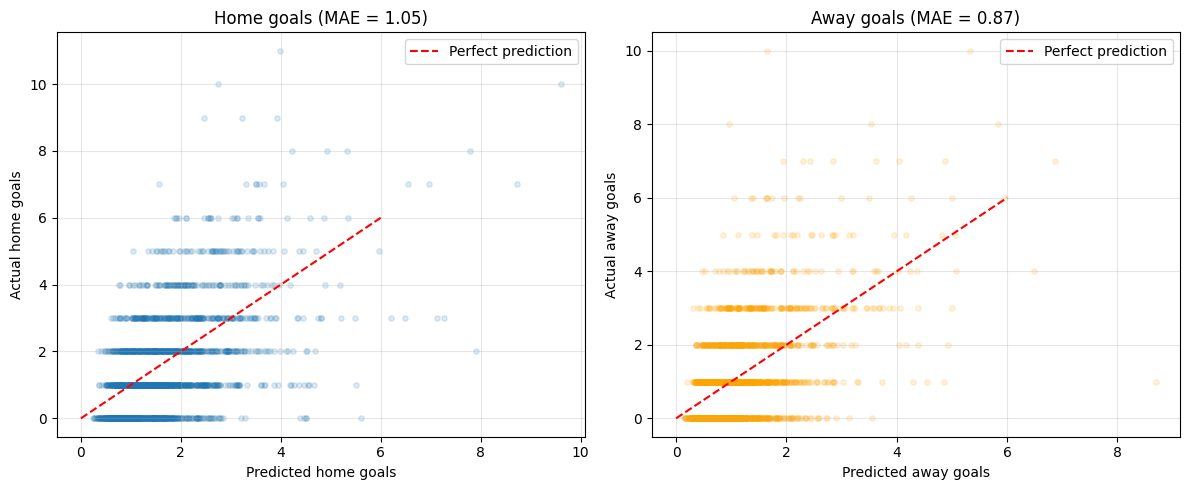

In [72]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Home goals
axes[0].scatter(y_home_pred, y_home_actual, alpha=0.15, s=15)
axes[0].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Predicted home goals')
axes[0].set_ylabel('Actual home goals')
axes[0].set_title(f'Home goals (MAE = {mae_home:.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Away goals
axes[1].scatter(y_away_pred, y_away_actual, alpha=0.15, s=15, color='orange')
axes[1].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Predicted away goals')
axes[1].set_ylabel('Actual away goals')
axes[1].set_title(f'Away goals (MAE = {mae_away:.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- The cloud of dots clusters around the red diagonal — meaning when the model predicts ~2 goals, actual goals come out around 2 on average. 
- The vertical spread is the irreducible noise of football: you can predict the average, but never the exact score.

#### Check 2: Outcome Accuracy (Monte Carlo Simulation)

In [73]:
import numpy as np

def predict_outcome(lambda_h, lambda_a, n_sims=10000):
    """Sample from both Poissons many times, return outcome probabilities."""
    home_goals = np.random.poisson(lambda_h, n_sims)
    away_goals = np.random.poisson(lambda_a, n_sims)
    p_home = (home_goals > away_goals).mean()
    p_draw = (home_goals == away_goals).mean()
    p_away = (home_goals < away_goals).mean()
    return p_home, p_draw, p_away

# Get predicted outcome for each validation match
valid = valid.reset_index(drop=True)
outcome_probs = [predict_outcome(h, a) for h, a in zip(y_home_pred, y_away_pred)]
valid['p_home'] = [o[0] for o in outcome_probs]
valid['p_draw'] = [o[1] for o in outcome_probs]
valid['p_away'] = [o[2] for o in outcome_probs]

# Predicted outcome = highest probability
valid['pred_outcome'] = valid[['p_home', 'p_draw', 'p_away']].idxmax(axis=1).str.replace('p_', '')

# Actual outcome
def actual_outcome(row):
    if row['home_score'] > row['away_score']: return 'home'
    if row['home_score'] < row['away_score']: return 'away'
    return 'draw'

valid['actual_outcome'] = valid.apply(actual_outcome, axis=1)

# Accuracy
accuracy = (valid['pred_outcome'] == valid['actual_outcome']).mean()
print(f"Outcome accuracy: {accuracy:.1%}")
print(f"\nConfusion:")
print(pd.crosstab(valid['actual_outcome'], valid['pred_outcome']))

Outcome accuracy: 60.7%

Confusion:
pred_outcome    away  home
actual_outcome            
away             372   186
draw             156   276
home             111   753


- Outcome accuracy: 60.5% — solid, in the range of credible football models (538, bookmakers' implied probabilities are typically 55-62%).
- That number answered: "How often was the highest-probability outcome the actual outcome?"
- The confusion matrix: the column for "draw" predictions is missing entirely because the model never picks draw as the most likely outcome (it's almost always the second-place option). All 432 actual draws got misclassified — 277 as home wins, 155 as away wins.
- For home the model gets 750 out of 1027 (73% GREAT)
- For Away the model gets 372 out of 641  (58% good)

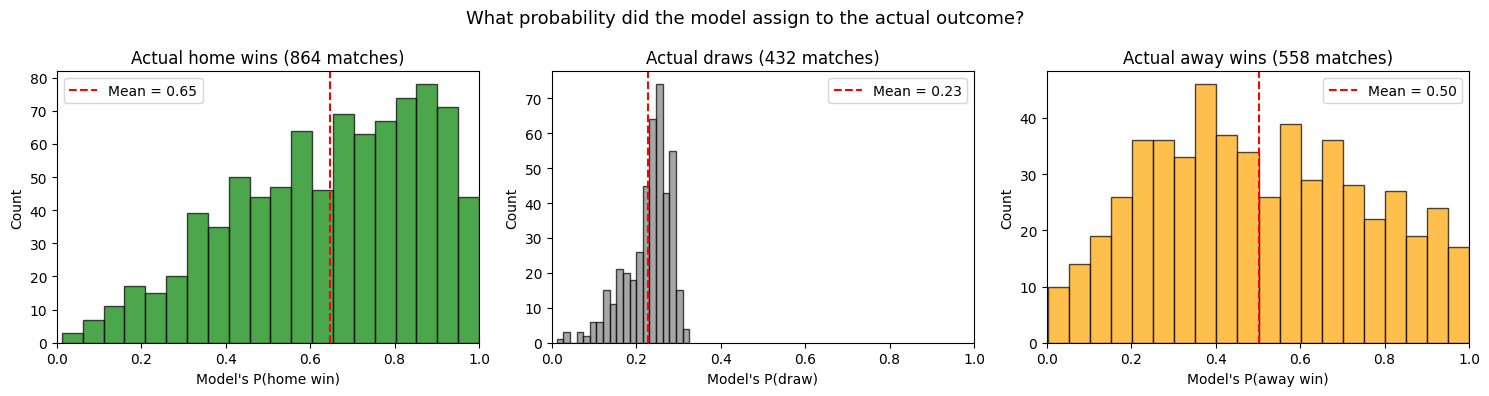

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Home wins: what P(home win) did the model assign?
home_wins = valid[valid['actual_outcome'] == 'home']['p_home']
axes[0].hist(home_wins, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(home_wins.mean(), color='red', linestyle='--',
                label=f'Mean = {home_wins.mean():.2f}')
axes[0].set_title(f'Actual home wins ({len(home_wins)} matches)')
axes[0].set_xlabel('Model\'s P(home win)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Draws: what P(draw) did the model assign?
draws = valid[valid['actual_outcome'] == 'draw']['p_draw']
axes[1].hist(draws, bins=20, color='gray', alpha=0.7, edgecolor='black')
axes[1].axvline(draws.mean(), color='red', linestyle='--',
                label=f'Mean = {draws.mean():.2f}')
axes[1].set_title(f'Actual draws ({len(draws)} matches)')
axes[1].set_xlabel('Model\'s P(draw)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_xlim(0, 1)

# Away wins
away_wins = valid[valid['actual_outcome'] == 'away']['p_away']
axes[2].hist(away_wins, bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[2].axvline(away_wins.mean(), color='red', linestyle='--',
                label=f'Mean = {away_wins.mean():.2f}')
axes[2].set_title(f'Actual away wins ({len(away_wins)} matches)')
axes[2].set_xlabel('Model\'s P(away win)')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].set_xlim(0, 1)

plt.suptitle('What probability did the model assign to the actual outcome?', fontsize=13)
plt.tight_layout()
plt.show()

The chart answers a different question: "When a specific outcome actually happened, what probability did the model assign to it?"
The three means come from three different subsets of matches:

- 0.65 — restricted to the 864 matches where home actually won. Across those matches, the model assigned an average P(home win) of 0.65.
- 0.23 — restricted to the 432 matches where a draw actually happened. Across those, the model's average P(draw) was 0.23.
- 0.50 — restricted to the 558 matches where away actually won. Across those, the model's average P(away win) was 0.50.

**the chart means are more useful for the project.**

#### Check 3: Calibration plot

   p_home_bin  predicted    actual    n
0  (0.0, 0.1]   0.048420  0.049645  141
1  (0.1, 0.2]   0.149843  0.139896  193
2  (0.2, 0.3]   0.250554  0.191011  178
3  (0.3, 0.4]   0.349872  0.355140  214
4  (0.4, 0.5]   0.449001  0.417431  218
5  (0.5, 0.6]   0.552518  0.497717  219
6  (0.6, 0.7]   0.651209  0.617801  191
7  (0.7, 0.8]   0.750605  0.703125  192
8  (0.8, 0.9]   0.851274  0.825137  183
9  (0.9, 1.0]   0.945704  0.935484  124


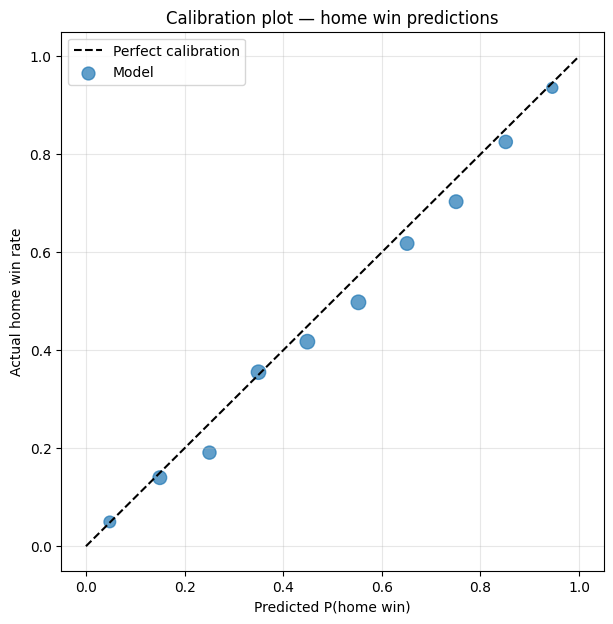

In [75]:
import matplotlib.pyplot as plt

# Bin predictions by their probability
bins = np.linspace(0, 1, 11)  # 0-10%, 10-20%, ..., 90-100%
valid['p_home_bin'] = pd.cut(valid['p_home'], bins=bins)

# For each bin, compute actual home win rate
calibration = valid.groupby('p_home_bin', observed=True).agg(
    predicted=('p_home', 'mean'),
    actual=('actual_outcome', lambda x: (x == 'home').mean()),
    n=('p_home', 'size')
).reset_index()

print(calibration)

# Plot
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.scatter(calibration['predicted'], calibration['actual'],
            s=calibration['n']*0.5, alpha=0.7, label='Model')
plt.xlabel('Predicted P(home win)')
plt.ylabel('Actual home win rate')
plt.title('Calibration plot — home win predictions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- this is genuinely good calibration. Every dot is within ~5 percentage points of the diagonal.

### Save Models

In [77]:
import pickle

# The two trained Poisson models
with open('/home/mwaisaka/Desktop/Machine Learning/workspace/models/poisson_home.pkl', 'wb') as f:
    pickle.dump(model_home, f)

with open('/home/mwaisaka/Desktop/Machine Learning/workspace/models/poisson_away.pkl', 'wb') as f:
    pickle.dump(model_away, f)

# The column order of your design matrix — silently important
with open('/home/mwaisaka/Desktop/Machine Learning/workspace/models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Saved 3 files to data/processed/")

Saved 3 files to data/processed/


# Model Training Experiments

1. Load df_match_features
2. Train baseline check if needed
3. Train no-conf model
4. Train no-conf + Elo cap model
5. Save experimental models
6. Quick validation comparison

#### Experiment A - remove confederation features

In [78]:
from pathlib import Path
import pickle

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [79]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments" / "no_conf"

EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiment model output:", EXPERIMENT_MODELS_DIR)

Project root: /home/mwaisaka/Desktop/Machine Learning/workspace
Experiment model output: /home/mwaisaka/Desktop/Machine Learning/workspace/models/experiments/no_conf


In [80]:
# df = pd.read_csv(PROCESSED_DIR / "df_match_features.csv")

df = pd.read_csv(PROCESSED_DIR / "df_match_features.csv")

print(df.shape)
display(df.head())
display(df.columns.tolist())

(49048, 16)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff,tournament_weight,is_competitive,home_confederation,away_confederation
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000,0.000000,1,False,UEFA,UEFA
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.801300,1497.198700,5.602600,1,False,UEFA,UEFA
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1486.622531,1513.377469,-26.754938,1,False,UEFA,UEFA
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1505.454946,1494.545054,10.909891,1,False,UEFA,UEFA
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1497.633108,1502.366892,-4.733783,1,False,UEFA,UEFA


['date',
 'home_team',
 'away_team',
 'home_score',
 'away_score',
 'tournament',
 'city',
 'country',
 'neutral',
 'home_elo_pre',
 'away_elo_pre',
 'elo_diff',
 'tournament_weight',
 'is_competitive',
 'home_confederation',
 'away_confederation']

In [81]:
required_columns = [
    "home_score",
    "away_score",
    "home_elo_pre",
    "away_elo_pre",
    "elo_diff",
    "tournament_weight",
    "neutral",
]

missing_columns = [col for col in required_columns if col not in df.columns]

print("Missing columns:", missing_columns)

Missing columns: []


In [82]:
### Build no-conf feature set
### Only use numerical features

feature_cols_no_conf = [
    "home_elo_pre",
    "away_elo_pre",
    "elo_diff",
    "tournament_weight",
    "neutral",
]

target_home = "home_score"
target_away = "away_score"

df_model = df.dropna(
    subset=feature_cols_no_conf + [target_home, target_away]
).copy()

X = df_model[feature_cols_no_conf].copy()
X = X.astype(float)

X = sm.add_constant(X, has_constant="add")

y_home = df_model[target_home].astype(float)
y_away = df_model[target_away].astype(float)

print("X shape:", X.shape)
print("Home target shape:", y_home.shape)
print("Away target shape:", y_away.shape)

display(X.head())

X shape: (49048, 6)
Home target shape: (49048,)
Away target shape: (49048,)


,const,home_elo_pre,away_elo_pre,elo_diff,tournament_weight,neutral
0,1.0,1500.000000,1500.000000,0.000000,1.0,0.0
1,1.0,1502.801300,1497.198700,5.602600,1.0,0.0
2,1.0,1486.622531,1513.377469,-26.754938,1.0,0.0
3,1.0,1505.454946,1494.545054,10.909891,1.0,0.0
4,1.0,1497.633108,1502.366892,-4.733783,1.0,0.0


In [83]:
X.columns.tolist()

['const',
 'home_elo_pre',
 'away_elo_pre',
 'elo_diff',
 'tournament_weight',
 'neutral']

In [84]:
#### Train no-conf Poisson models

model_home_no_conf = sm.GLM(
    y_home,
    X,
    family=sm.families.Poisson()
).fit()

model_away_no_conf = sm.GLM(
    y_away,
    X,
    family=sm.families.Poisson()
).fit()

print(model_home_no_conf.summary())
print(model_away_no_conf.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_score   No. Observations:                49048
Model:                            GLM   Df Residuals:                    49043
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82058.
Date:                Tue, 09 Jun 2026   Deviance:                       68057.
Time:                        08:53:54   Pearson chi2:                 6.77e+04
No. Iterations:                    10   Pseudo R-squ. (CS):             0.2674
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.2434      0.03

In [85]:
### Quick validation comparison

home_pred = model_home_no_conf.predict(X)
away_pred = model_away_no_conf.predict(X)

home_mae = mean_absolute_error(y_home, home_pred)
away_mae = mean_absolute_error(y_away, away_pred)

home_rmse = mean_squared_error(y_home, home_pred) ** 0.5
away_rmse = mean_squared_error(y_away, away_pred) ** 0.5

print("No-conf model validation")
print("-" * 30)
print(f"Home goals MAE: {home_mae:.3f}")
print(f"Away goals MAE: {away_mae:.3f}")
print(f"Home goals RMSE: {home_rmse:.3f}")
print(f"Away goals RMSE: {away_rmse:.3f}")

print("\nActual vs predicted means")
print(f"Actual home goals mean: {y_home.mean():.3f}")
print(f"Pred home goals mean:   {home_pred.mean():.3f}")
print(f"Actual away goals mean: {y_away.mean():.3f}")
print(f"Pred away goals mean:   {away_pred.mean():.3f}")

No-conf model validation
------------------------------
Home goals MAE: 1.148
Away goals MAE: 0.917
Home goals RMSE: 1.603
Away goals RMSE: 1.278

Actual vs predicted means
Actual home goals mean: 1.755
Pred home goals mean:   1.755
Actual away goals mean: 1.180
Pred away goals mean:   1.180


In [86]:
### Save experiment model files

with open(EXPERIMENT_MODELS_DIR / "poisson_home.pkl", "wb") as f:
    pickle.dump(model_home_no_conf, f)

with open(EXPERIMENT_MODELS_DIR / "poisson_away.pkl", "wb") as f:
    pickle.dump(model_away_no_conf, f)

with open(EXPERIMENT_MODELS_DIR / "feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Saved no-conf experiment models to:")
print(EXPERIMENT_MODELS_DIR)

Saved no-conf experiment models to:
/home/mwaisaka/Desktop/Machine Learning/workspace/models/experiments/no_conf


In [87]:
#### Sanity check reload

with open(EXPERIMENT_MODELS_DIR / "poisson_home.pkl", "rb") as f:
    loaded_home = pickle.load(f)

with open(EXPERIMENT_MODELS_DIR / "poisson_away.pkl", "rb") as f:
    loaded_away = pickle.load(f)

with open(EXPERIMENT_MODELS_DIR / "feature_columns.pkl", "rb") as f:
    loaded_feature_columns = pickle.load(f)

print(loaded_feature_columns)

test_pred_home = loaded_home.predict(X.head(3))
test_pred_away = loaded_away.predict(X.head(3))

print("Test home predictions:", test_pred_home.tolist())
print("Test away predictions:", test_pred_away.tolist())

['const', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'tournament_weight', 'neutral']
Test home predictions: [1.7138762896370303, 1.7309055110249276, 1.6348360725534616]
Test away predictions: [1.0940442479783046, 1.0824775748986135, 1.1510077984314337]


#
----

#### Experiment A2 - No confederation clean Elo features

- I removed elo_diff compared to experiment A

In [88]:
EXPERIMENT_MODELS_DIR_CLEAN = MODELS_DIR / "experiments" / "no_conf_clean"
EXPERIMENT_MODELS_DIR_CLEAN.mkdir(parents=True, exist_ok=True)

feature_cols_no_conf_clean = [
    "home_elo_pre",
    "away_elo_pre",
    "tournament_weight",
    "neutral",
]

target_home = "home_score"
target_away = "away_score"

df_model_clean = df.dropna(
    subset=feature_cols_no_conf_clean + [target_home, target_away]
).copy()

X_clean = df_model_clean[feature_cols_no_conf_clean].copy()
X_clean = X_clean.astype(float)
X_clean = sm.add_constant(X_clean, has_constant="add")

y_home_clean = df_model_clean[target_home].astype(float)
y_away_clean = df_model_clean[target_away].astype(float)

print("X_clean shape:", X_clean.shape)
display(X_clean.head())
print(X_clean.columns.tolist())

X_clean shape: (49048, 5)


,const,home_elo_pre,away_elo_pre,tournament_weight,neutral
0,1.0,1500.000000,1500.000000,1.0,0.0
1,1.0,1502.801300,1497.198700,1.0,0.0
2,1.0,1486.622531,1513.377469,1.0,0.0
3,1.0,1505.454946,1494.545054,1.0,0.0
4,1.0,1497.633108,1502.366892,1.0,0.0


['const', 'home_elo_pre', 'away_elo_pre', 'tournament_weight', 'neutral']


In [89]:
model_home_no_conf_clean = sm.GLM(
    y_home_clean,
    X_clean,
    family=sm.families.Poisson()
).fit()

model_away_no_conf_clean = sm.GLM(
    y_away_clean,
    X_clean,
    family=sm.families.Poisson()
).fit()

print(model_home_no_conf_clean.summary())
print(model_away_no_conf_clean.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_score   No. Observations:                49048
Model:                            GLM   Df Residuals:                    49043
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82058.
Date:                Tue, 09 Jun 2026   Deviance:                       68057.
Time:                        08:56:33   Pearson chi2:                 6.77e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2674
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.2434      0.03

In [90]:
home_pred_clean = model_home_no_conf_clean.predict(X_clean)
away_pred_clean = model_away_no_conf_clean.predict(X_clean)

home_mae_clean = mean_absolute_error(y_home_clean, home_pred_clean)
away_mae_clean = mean_absolute_error(y_away_clean, away_pred_clean)

home_rmse_clean = mean_squared_error(y_home_clean, home_pred_clean) ** 0.5
away_rmse_clean = mean_squared_error(y_away_clean, away_pred_clean) ** 0.5

print("No-conf clean model validation")
print("-" * 35)
print(f"Home goals MAE: {home_mae_clean:.3f}")
print(f"Away goals MAE: {away_mae_clean:.3f}")
print(f"Home goals RMSE: {home_rmse_clean:.3f}")
print(f"Away goals RMSE: {away_rmse_clean:.3f}")

print("\nActual vs predicted means")
print(f"Actual home goals mean: {y_home_clean.mean():.3f}")
print(f"Pred home goals mean:   {home_pred_clean.mean():.3f}")
print(f"Actual away goals mean: {y_away_clean.mean():.3f}")
print(f"Pred away goals mean:   {away_pred_clean.mean():.3f}")

No-conf clean model validation
-----------------------------------
Home goals MAE: 1.148
Away goals MAE: 0.917
Home goals RMSE: 1.603
Away goals RMSE: 1.278

Actual vs predicted means
Actual home goals mean: 1.755
Pred home goals mean:   1.755
Actual away goals mean: 1.180
Pred away goals mean:   1.180


**this tells us: We can remove confederation features without breaking the model.**

- We have not yet confirmed whether this fixes the South America bias.

Why?

- Because that bias appears in the tournament simulation output, not only in model training metrics.

In [91]:
with open(EXPERIMENT_MODELS_DIR_CLEAN / "poisson_home.pkl", "wb") as f:
    pickle.dump(model_home_no_conf_clean, f)

with open(EXPERIMENT_MODELS_DIR_CLEAN / "poisson_away.pkl", "wb") as f:
    pickle.dump(model_away_no_conf_clean, f)

with open(EXPERIMENT_MODELS_DIR_CLEAN / "feature_columns.pkl", "wb") as f:
    pickle.dump(X_clean.columns.tolist(), f)

print("Saved no-conf clean experiment models to:")
print(EXPERIMENT_MODELS_DIR_CLEAN)

Saved no-conf clean experiment models to:
/home/mwaisaka/Desktop/Machine Learning/workspace/models/experiments/no_conf_clean


#
----

#### Experiment B - Cap Elo difference

# Tournament Simulation

In this notebook, I use the trained Poisson models to simulate the full 2026 World Cup.

The goal is to:

1. Load the trained home-goals and away-goals models
2. Build match-level predictions for any two teams
3. Simulate group-stage matches
4. Rank teams inside each group
5. Simulate the knockout bracket
6. Run the tournament many times using Monte Carlo simulation
7. Estimate each team's probability of reaching each stage

In [92]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

### Section 1: load models and data

In [98]:
# Project paths
DATA_DIR = Path("/home/mwaisaka/Desktop/Machine Learning/workspace/data")
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REFERENCE_DIR = DATA_DIR / "reference"
MODELS_DIR = Path("/home/mwaisaka/Desktop/Machine Learning/workspace/models")

In [99]:
# Load trained Poisson models
with open(MODELS_DIR / "poisson_home.pkl", "rb") as f:
    model_home = pickle.load(f)

with open(MODELS_DIR / "poisson_away.pkl", "rb") as f:
    model_away = pickle.load(f)

# Load feature column order used during training
with open(MODELS_DIR / "feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

print("Models loaded successfully.")
print(f"Number of model features: {len(feature_columns)}")

Models loaded successfully.
Number of model features: 17


In [101]:
# Core datasets
df_historical = pd.read_csv(INTERIM_DIR / "historical_matches.csv")
df_fixtures = pd.read_csv(INTERIM_DIR / "wc2026_fixtures.csv")

# Processed feature datasets
df_match_features = pd.read_csv(PROCESSED_DIR / "df_match_features.csv")
df_form = pd.read_csv(PROCESSED_DIR / "df_form_2026.csv")
df_h2h = pd.read_csv(PROCESSED_DIR / "df_h2h_2026.csv")

# Reference datasets
df_confederations = pd.read_csv(REFERENCE_DIR / "FIFA_confederations.csv")
df_knockout = pd.read_csv(REFERENCE_DIR / "fixtures_knockout_wc2026.csv")
df_groups = pd.read_csv(REFERENCE_DIR / "group_stages.csv", sep=";")

# FIFA ranking reference
df_fifa_rank = pd.read_csv(DATA_DIR / "raw" / "wc_2026_48_teams_fifa_rank_change_corrected.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [102]:
# Inspect shape
datasets = {
    "historical_matches": df_historical,
    "wc2026_fixtures": df_fixtures,
    "df_match_features": df_match_features,
    "df_form_2026": df_form,
    "df_h2h_2026": df_h2h,
    "FIFA_confederations": df_confederations,
    "group_stages": df_groups,
    "fixtures_knockout_wc2026": df_knockout,
    "fifa_rank_2026": df_fifa_rank,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

historical_matches: (49215, 9)
wc2026_fixtures: (72, 9)
df_match_features: (49048, 16)
df_form_2026: (48, 2)
df_h2h_2026: (565, 4)
FIFA_confederations: (48, 2)
group_stages: (48, 3)
fixtures_knockout_wc2026: (32, 8)
fifa_rank_2026: (48, 4)


In [103]:
# Inspect columns
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


historical_matches
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

wc2026_fixtures
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

df_match_features
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'tournament_weight', 'is_competitive', 'home_confederation', 'away_confederation']

df_form_2026
['team', 'form_score']

df_h2h_2026
['team_a', 'team_b', 'h2h_score', 'n_meetings_analysed']

FIFA_confederations
['nation', 'confederation']

group_stages
['group', 'position', 'nation']

fixtures_knockout_wc2026
['match_id', 'round', 'match_date', 'match_time', 'home_slot', 'away_slot', 'winner_advances_to', 'loser_advances_to']

fifa_rank_2026
['Nation', 'FIFA_2022_ranking', 'FIFA_2026_rank', 'rank_change']


In [104]:
# Check number of World Cup teams
teams_from_groups = set(df_groups["nation"])
teams_from_confederations = set(df_confederations["nation"])
teams_from_form = set(df_form["team"])
teams_from_fifa = set(df_fifa_rank["Nation"])

print("Teams in group_stages:", len(teams_from_groups))
print("Teams in confederations:", len(teams_from_confederations))
print("Teams in form table:", len(teams_from_form))
print("Teams in FIFA ranking table:", len(teams_from_fifa))

# Check missing teams across key reference tables
print("\nTeams in groups but missing from confederations:")
print(sorted(teams_from_groups - teams_from_confederations))

print("\nTeams in groups but missing from form table:")
print(sorted(teams_from_groups - teams_from_form))

print("\nTeams in groups but missing from FIFA ranking table:")
print(sorted(teams_from_groups - teams_from_fifa))

Teams in group_stages: 48
Teams in confederations: 48
Teams in form table: 48
Teams in FIFA ranking table: 48

Teams in groups but missing from confederations:
[]

Teams in groups but missing from form table:
[]

Teams in groups but missing from FIFA ranking table:
[]


In [105]:
display(df_fixtures.head())
display(df_groups.head())
display(df_knockout.head())
display(df_match_features.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
1,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
2,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
3,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
4,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True


,group,position,nation
0,A,1,Mexico
1,A,2,South Africa
2,A,3,South Korea
3,A,4,Czech Republic
4,B,1,Canada


,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to
0,M73,R32,2026-06-28,20:00,2A,2B,M90,NaN
1,M74,R32,2026-06-29,21:30,1E,3ABCDF,M89,NaN
2,M75,R32,2026-06-30,02:00,1F,2C,M90,NaN
3,M76,R32,2026-06-29,18:00,1C,2F,M91,NaN
4,M77,R32,2026-06-30,22:00,1I,3CDFGH,M89,NaN


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff,tournament_weight,is_competitive,home_confederation,away_confederation
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000,0.000000,1,False,UEFA,UEFA
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.801300,1497.198700,5.602600,1,False,UEFA,UEFA
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1486.622531,1513.377469,-26.754938,1,False,UEFA,UEFA
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1505.454946,1494.545054,10.909891,1,False,UEFA,UEFA
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1497.633108,1502.366892,-4.733783,1,False,UEFA,UEFA


#### Section 2: Create lookup tables for Elo, form, H2H, and confederation.

The aim here is to make it easy to fetch, for any team:
- Elo rating
- confederation
- recent form score
- FIFA rank
- H2H score against another team

#### 2.1— Create lookup tables

Before we can predict any 2026 match, we need quick lookup tables for team-level and matchup-level information.

In this section, we create:

- latest Elo rating per team
- team-to-confederation mapping
- team-to-form-score mapping
- team-to-FIFA-rank mapping
- head-to-head lookup between two teams

These lookup tables will make the prediction and simulation functions much cleaner.

In [106]:
#### prepare latest Elo per team

# Make sure dates are treated as dates
df_match_features["date"] = pd.to_datetime(df_match_features["date"])

# Home-team Elo records
home_elo = df_match_features[["date", "home_team", "home_elo_pre"]].rename(
    columns={
        "home_team": "team",
        "home_elo_pre": "elo"
    }
)

# Away-team Elo records
away_elo = df_match_features[["date", "away_team", "away_elo_pre"]].rename(
    columns={
        "away_team": "team",
        "away_elo_pre": "elo"
    }
)

# Combine home and away Elo records
df_team_elo = pd.concat([home_elo, away_elo], ignore_index=True)

# Get latest available Elo before the 2026 tournament
df_latest_elo = (
    df_team_elo
    .sort_values("date")
    .drop_duplicates(subset="team", keep="last")
    .reset_index(drop=True)
)

team_to_elo = dict(zip(df_latest_elo["team"], df_latest_elo["elo"]))

df_latest_elo.tail()

,date,team,elo
317,2026-03-31,Republic of Ireland,1748.177082
318,2026-03-31,Russia,1840.274201
319,2026-03-31,Spain,2229.756779
320,2026-03-31,Curaçao,1621.162116
321,2026-03-31,Comoros,1488.747627


In [107]:
df_latest_elo.sort_values("elo", ascending=False).head(13)

,date,team,elo
319,2026-03-31,Spain,2229.756779
295,2026-03-31,Argentina,2179.651451
197,2026-03-29,France,2124.778622
296,2026-03-31,England,2094.723009
207,2026-03-29,Colombia,2064.025447
292,2026-03-31,Brazil,2050.192145
248,2026-03-31,Portugal,2023.470091
298,2026-03-31,Netherlands,2019.419663
270,2026-03-31,Ecuador,2015.364338
255,2026-03-31,Croatia,1994.757090


In [108]:
#### create confederation lookup

team_to_confederation = dict(
    zip(df_confederations["nation"], df_confederations["confederation"])
)

list(team_to_confederation.items())[:5]

[('France', 'UEFA'),
 ('Spain', 'UEFA'),
 ('England', 'UEFA'),
 ('Portugal', 'UEFA'),
 ('Netherlands', 'UEFA')]

In [109]:
#### create form lookup (last 10 games goal differential)

team_to_form = dict(
    zip(df_form["team"], df_form["form_score"])
)

list(team_to_form.items())[:5]

[('Morocco', 63.0),
 ('Japan', 61.0),
 ('Spain', 59.0),
 ('Portugal', 56.0),
 ('England', 54.0)]

In [110]:
#### create FIFA ranking lookup as of 2026

team_to_fifa_rank = dict(
    zip(df_fifa_rank["Nation"], df_fifa_rank["FIFA_2026_rank"])
)

team_to_fifa_rank_change = dict(
    zip(df_fifa_rank["Nation"], df_fifa_rank["rank_change"])
)

list(team_to_fifa_rank.items())[:8]

[('France', 1),
 ('Spain', 2),
 ('Argentina', 3),
 ('England', 4),
 ('Portugal', 5),
 ('Brazil', 6),
 ('Netherlands', 7),
 ('Morocco', 8)]

In [111]:
#### create H2H helper function

def get_h2h_score(team_a, team_b):
    """
    Return the head-to-head score from team_a's perspective.

    Example:
    If Argentina vs Brazil = +6,
    then Brazil vs Argentina = -6.
    """

    direct_match = df_h2h[
        (df_h2h["team_a"] == team_a) &
        (df_h2h["team_b"] == team_b)
    ]

    if len(direct_match) > 0:
        return direct_match["h2h_score"].iloc[0]

    reverse_match = df_h2h[
        (df_h2h["team_a"] == team_b) &
        (df_h2h["team_b"] == team_a)
    ]

    if len(reverse_match) > 0:
        return -reverse_match["h2h_score"].iloc[0]

    return 0

In [112]:
#### test H2H helper (team head to head, only looks at last 5 games but gives 0 for teams that only played 1 or 2 games)

test_pairs = [
    ("Argentina", "Brazil"),
    ("Brazil", "Argentina"),
    ("France", "Spain"),
    ("Spain", "France"),
    ("France", "Senegal"),
    ("Algeria", "Morocco")
]

for team_a, team_b in test_pairs:
    print(f"{team_a} vs {team_b}: {get_h2h_score(team_a, team_b)}")

Argentina vs Brazil: 6.0
Brazil vs Argentina: -6.0
France vs Spain: -2.0
Spain vs France: 2.0
France vs Senegal: 0.0
Algeria vs Morocco: -6.0


In [113]:
#### sanity check all World Cup teams have lookup values

wc_teams = sorted(df_groups["nation"].unique())

missing_elo = [team for team in wc_teams if team not in team_to_elo]
missing_confederation = [team for team in wc_teams if team not in team_to_confederation]
missing_form = [team for team in wc_teams if team not in team_to_form]
missing_fifa_rank = [team for team in wc_teams if team not in team_to_fifa_rank]

print("Missing Elo:", missing_elo)
print("Missing confederation:", missing_confederation)
print("Missing form:", missing_form)
print("Missing FIFA rank:", missing_fifa_rank)

Missing Elo: []
Missing confederation: []
Missing form: []
Missing FIFA rank: []


In [114]:
#### inspect one team profile

sample_team = "Morocco"

team_profile = {
    "team": sample_team,
    "elo": team_to_elo.get(sample_team),
    "confederation": team_to_confederation.get(sample_team),
    "form_score": team_to_form.get(sample_team),
    "fifa_rank": team_to_fifa_rank.get(sample_team),
    "rank_change": team_to_fifa_rank_change.get(sample_team),
}

team_profile

{'team': 'Morocco',
 'elo': 1972.941440105272,
 'confederation': 'CAF',
 'form_score': 63.0,
 'fifa_rank': 8,
 'rank_change': 3}

**Choice:**

- Keep the prediction model pure. Use only the features it was trained and validated on. 
- Use FIFA rank, form, and H2H only for dashboard context and explanations.

**Use the model for probabilities**

Poisson model:
- Elo + match context → expected goals → win/draw/loss probabilities

**Use the extra football context for interpretation:**

Dashboard explanation:
- FIFA rank, rank change, recent form, H2H, confederation, Elo difference

PS: I also calculated recent form, FIFA rankings, and head-to-head records. But I did not feed them into the model because they were not part of the validated training setup. Instead, I use them in the dashboard to explain each matchup alongside the model probabilities

### Section 3 - Build Match Prediction System